# **ResNet50 for Plant Disease Detection**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Set your data and model paths
data_dir = '/content/drive/MyDrive/leaf/valid'
model_path = '/content/resnet50_model.h5'

# Set parameters
batch_size = 32
image_size = (224, 224)  # ResNet50 input size
epochs = 44

In [ ]:
# Data preprocessing
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 1864 images belonging to 5 classes.
Found 465 images belonging to 5 classes.


In [ ]:
# Create the ResNet50 model
base_model = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

Epoch 1/44
59/59 [==============================] - 18s 171ms/step - loss: 1.6319 - accuracy: 0.2881 - val_loss: 1.4589 - val_accuracy: 0.4151
Epoch 2/44
59/59 [==============================] - 9s 149ms/step - loss: 1.4105 - accuracy: 0.3991 - val_loss: 1.3046 - val_accuracy: 0.5140
Epoch 3/44
59/59 [==============================] - 8s 141ms/step - loss: 1.2821 - accuracy: 0.4769 - val_loss: 1.2140 - val_accuracy: 0.5656
Epoch 4/44
59/59 [==============================] - 9s 150ms/step - loss: 1.1884 - accuracy: 0.5220 - val_loss: 1.1044 - val_accuracy: 0.6043
Epoch 5/44
59/59 [==============================] - 8s 140ms/step - loss: 1.1232 - accuracy: 0.5327 - val_loss: 1.0659 - val_accuracy: 0.5828
Epoch 6/44
59/59 [==============================] - 9s 150ms/step - loss: 1.0548 - accuracy: 0.5756 - val_loss: 0.9646 - val_accuracy: 0.6151
Epoch 7/44
59/59 [==============================] - 8s 138ms/step - loss: 0.9928 - accuracy: 0.6009 - val_loss: 0.9203 - val_accuracy: 0.6624
Epoch

In [ ]:
# Save the model
model.save(model_path)

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {accuracy * 100:.2f}%')

15/15 [==============================] - 2s 108ms/step - loss: 0.4005 - accuracy: 0.8946
Validation Accuracy: 89.46%


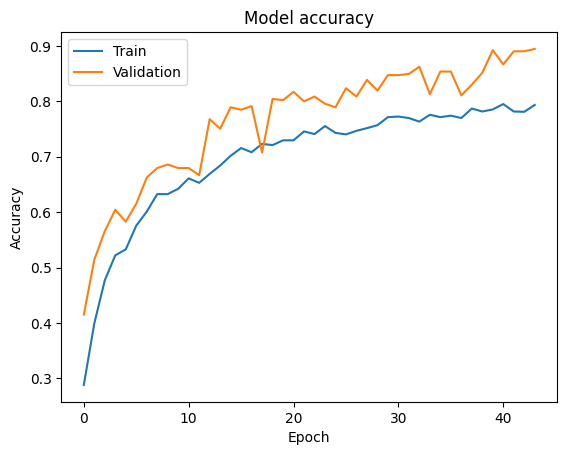

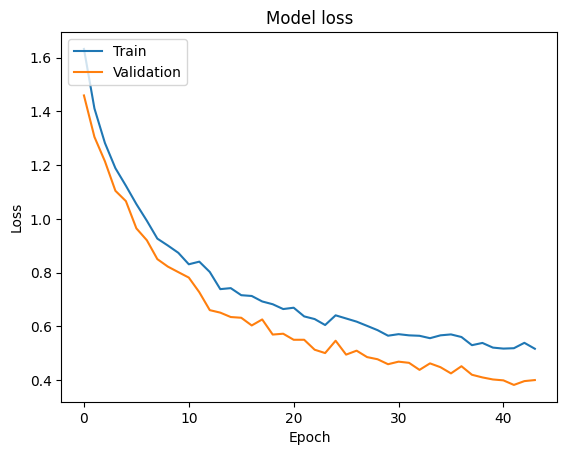

In [ ]:
# Visualize training history
def plot_training_history(history):
    # Plot training & validation accuracy values
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

    # Plot training & validation loss values
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

plot_training_history(history)

15/15 [==============================] - 2s 105ms/step


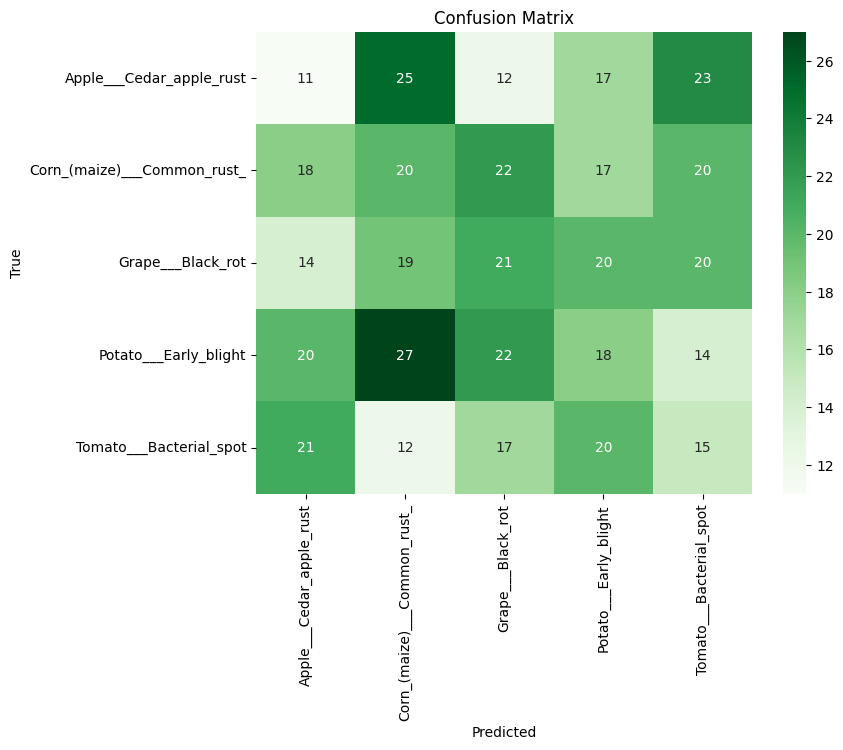

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
# Generate predictions
y_true = validation_generator.classes
y_pred = np.argmax(model.predict(validation_generator), axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', xticklabels=train_generator.class_indices.keys(), yticklabels=train_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
# Classification report
class_labels = list(train_generator.class_indices.keys())
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))


Classification Report:
                              precision    recall  f1-score   support

   Apple___Cedar_apple_rust       0.13      0.12      0.13        88
Corn_(maize)___Common_rust_       0.19      0.21      0.20        97
          Grape___Black_rot       0.22      0.22      0.22        94
      Potato___Early_blight       0.20      0.18      0.19       101
    Tomato___Bacterial_spot       0.16      0.18      0.17        85

                   accuracy                           0.18       465
                  macro avg       0.18      0.18      0.18       465
               weighted avg       0.18      0.18      0.18       465

